In [2]:
params <- list(
    ps_raw = "data/temp/ps_raw.rds",
    ps_vst = "data/temp/ps_vst.rds",
    ps_core = "data/temp/ps_core.rds",
    ps_core_vst =  "data/temp/ps_core_vst.rds",
    euc_dist_core = "results/ASVs_euclidean_core_distance.tsv"
)

In [3]:
set.seed(8092003)

In [4]:
library(phyloseq)
library(dplyr)
library(microbiome)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2


microbiome R package (microbiome.github.com)
    


 Copyright (C) 2011-2025 Leo Lahti, 
    Sudarshan Shetty et al. <microbiome.github.io>
    
 
    Note: we recommend switching to the SummarizedExperiment
    framework, see microbiome.github.io/OMA and the mia package.
    Minimum maintenance is provided microbiome R package but the
    development efforts have switched to mia.


Attaching package: ‘microbiome’


The following object is masked from ‘package:ggplot2’:

    alpha


The following object is masked from ‘package:base’:

    transform




In [5]:
ps_raw <- readRDS(params$ps_raw)
ps_core <- readRDS(params$ps_core)
ps_core_vst <- readRDS(params$ps_core_vst)

euc_dist_core <- as.dist(as.matrix(read.csv(
    params$euc_dist_core,
    sep='\t',
    header=T,
    row.names=1
)))

meta <- data.frame(sample_data(ps_core))

In [6]:
microbiome::summarize_phyloseq(ps_raw)
ntaxa(ps_raw)
ps_raw

Compositional = NO2

1] Min. number of reads = 4172] Max. number of reads = 1004533] Total number of reads = 23953814] Average number of reads = 29211.96341463415] Median number of reads = 26973.57] Sparsity = 0.8848441644408856] Any OTU sum to 1 or less? YES8] Number of singletons = 10929] Percent of OTUs that are singletons 
        (i.e. exactly one read detected across all samples)20.724995255266710] Number of sample variables are: 62ID_KYHhcd_dated_sexd_age_hcd_age_hc_grp_10yrd_age_hc_grp_5yrb_a9bd_education3_vsbd_phq9_sev_scorebd_phq9_dep_altbd_phq9_symptomcountbd_phq9_dep_catbd_phq9_any_depbd_phq9_mod_depb_e1b_e2b_e3b_e4b_e5b_e6b_e7b_e8b_e9b_e10lab_lc_w8lab_lc_w8blab_lc_w8ahc_c1hcd_c2g_g4hcd_c2g5hcd_c2g_f5hcd_c2g_g5hcd_c2g6hcd_c2g_f6hcd_c2g_g6hcd_c2g7hcd_c2g_f7hcd_c2g_g7hcd_c2g1hcd_c2g_f1hcd_c2g_g1hcd_c2g2hcd_c2g_f2hcd_c2g_g2hcd_c2g3hcd_c2g_f3hcd_c2g_g3hcd_c2g4hcd_c2g_f4atc1atc2atc3atc4atc5atc6atc7antidepressant_usageantibiotics_usageseasondepr_or_controlbatchnew_id2



[[1]]
[1] "1] Min. number of reads = 417"

[[2]]
[1] "2] Max. number of reads = 100453"

[[3]]
[1] "3] Total number of reads = 2395381"

[[4]]
[1] "4] Average number of reads = 29211.9634146341"

[[5]]
[1] "5] Median number of reads = 26973.5"

[[6]]
[1] "7] Sparsity = 0.884844164440885"

[[7]]
[1] "6] Any OTU sum to 1 or less? YES"

[[8]]
[1] "8] Number of singletons = 1092"

[[9]]
[1] "9] Percent of OTUs that are singletons \n        (i.e. exactly one read detected across all samples)20.7249952552667"

[[10]]
[1] "10] Number of sample variables are: 62"

[[11]]
 [1] "ID_KYH"               "hcd_date"             "d_sex"               
 [4] "d_age_hc"             "d_age_hc_grp_10yr"    "d_age_hc_grp_5yr"    
 [7] "b_a9"                 "bd_education3_vs"     "bd_phq9_sev_score"   
[10] "bd_phq9_dep_alt"      "bd_phq9_symptomcount" "bd_phq9_dep_cat"     
[13] "bd_phq9_any_dep"      "bd_phq9_mod_dep"      "b_e1"                
[16] "b_e2"                 "b_e3"                 "b_e4"                
[19] "b_e5"                 "b_e6"                 "b_e7"                
[22] "b_e8"                 "b_e9"                 "b_e10"               
[25] "lab_lc_w8"            "lab_lc_w8b"           "lab_lc_w8a"          
[28] "hc_c1"                "hcd_c2g_g4"           "hcd_c2g5"            
[31] "hcd_c2g_f5"           "hcd_c2g_g5"           "hcd_c2g6"            
[34] "hcd_c2g_f6"           "hcd_c2g_g6"           "hcd_c2g7"            
[37] "hcd_c2g_f7"           "hcd_c2g_g7"           "hcd_c2g1"            
[40] "hcd_c2g_f1"           "hcd_c2g_g1"           "hcd_c2g2"            
[43] "hcd_c2g_f2"           "hcd_c2g_g2"           "hcd_c2g3"            
[46] "hcd_c2g_f3"           "hcd_c2g_g3"           "hcd_c2g4"            
[49] "hcd_c2g_f4"           "atc1"                 "atc2"                
[52] "atc3"                 "atc4"                 "atc5"                
[55] "atc6"                 "atc7"                 "antidepressant_usage"
[58] "antibiotics_usage"    "season"               "depr_or_control"     
[61] "batch"                "new_id"

[1] 5269

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 5269 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 5269 taxa by 7 taxonomic ranks ]

In [7]:
microbiome::summarize_phyloseq(ps_core)
ntaxa(ps_core)
ps_core

Compositional = NO2

1] Min. number of reads = 4012] Max. number of reads = 858363] Total number of reads = 22387074] Average number of reads = 27301.30487804885] Median number of reads = 250647] Sparsity = 0.7189451429531526] Any OTU sum to 1 or less? NO8] Number of singletons = 09] Percent of OTUs that are singletons 
        (i.e. exactly one read detected across all samples)010] Number of sample variables are: 62ID_KYHhcd_dated_sexd_age_hcd_age_hc_grp_10yrd_age_hc_grp_5yrb_a9bd_education3_vsbd_phq9_sev_scorebd_phq9_dep_altbd_phq9_symptomcountbd_phq9_dep_catbd_phq9_any_depbd_phq9_mod_depb_e1b_e2b_e3b_e4b_e5b_e6b_e7b_e8b_e9b_e10lab_lc_w8lab_lc_w8blab_lc_w8ahc_c1hcd_c2g_g4hcd_c2g5hcd_c2g_f5hcd_c2g_g5hcd_c2g6hcd_c2g_f6hcd_c2g_g6hcd_c2g7hcd_c2g_f7hcd_c2g_g7hcd_c2g1hcd_c2g_f1hcd_c2g_g1hcd_c2g2hcd_c2g_f2hcd_c2g_g2hcd_c2g3hcd_c2g_f3hcd_c2g_g3hcd_c2g4hcd_c2g_f4atc1atc2atc3atc4atc5atc6atc7antidepressant_usageantibiotics_usageseasondepr_or_controlbatchnew_id2



[[1]]
[1] "1] Min. number of reads = 401"

[[2]]
[1] "2] Max. number of reads = 85836"

[[3]]
[1] "3] Total number of reads = 2238707"

[[4]]
[1] "4] Average number of reads = 27301.3048780488"

[[5]]
[1] "5] Median number of reads = 25064"

[[6]]
[1] "7] Sparsity = 0.718945142953152"

[[7]]
[1] "6] Any OTU sum to 1 or less? NO"

[[8]]
[1] "8] Number of singletons = 0"

[[9]]
[1] "9] Percent of OTUs that are singletons \n        (i.e. exactly one read detected across all samples)0"

[[10]]
[1] "10] Number of sample variables are: 62"

[[11]]
 [1] "ID_KYH"               "hcd_date"             "d_sex"               
 [4] "d_age_hc"             "d_age_hc_grp_10yr"    "d_age_hc_grp_5yr"    
 [7] "b_a9"                 "bd_education3_vs"     "bd_phq9_sev_score"   
[10] "bd_phq9_dep_alt"      "bd_phq9_symptomcount" "bd_phq9_dep_cat"     
[13] "bd_phq9_any_dep"      "bd_phq9_mod_dep"      "b_e1"                
[16] "b_e2"                 "b_e3"                 "b_e4"                
[19] "b_e5"                 "b_e6"                 "b_e7"                
[22] "b_e8"                 "b_e9"                 "b_e10"               
[25] "lab_lc_w8"            "lab_lc_w8b"           "lab_lc_w8a"          
[28] "hc_c1"                "hcd_c2g_g4"           "hcd_c2g5"            
[31] "hcd_c2g_f5"           "hcd_c2g_g5"           "hcd_c2g6"            
[34] "hcd_c2g_f6"           "hcd_c2g_g6"           "hcd_c2g7"            
[37] "hcd_c2g_f7"           "hcd_c2g_g7"           "hcd_c2g1"            
[40] "hcd_c2g_f1"           "hcd_c2g_g1"           "hcd_c2g2"            
[43] "hcd_c2g_f2"           "hcd_c2g_g2"           "hcd_c2g3"            
[46] "hcd_c2g_f3"           "hcd_c2g_g3"           "hcd_c2g4"            
[49] "hcd_c2g_f4"           "atc1"                 "atc2"                
[52] "atc3"                 "atc4"                 "atc5"                
[55] "atc6"                 "atc7"                 "antidepressant_usage"
[58] "antibiotics_usage"    "season"               "depr_or_control"     
[61] "batch"                "new_id"

[1] 1742

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1742 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 1742 taxa by 7 taxonomic ranks ]

In [8]:
meta$batch |> table()


B1 B2 
40 42 

In [9]:
predictors <- c(
    'depr_or_control', 
    # 'batch', 
    'd_sex', 
    'd_age_hc'
)
predictors <- predictors[meta[predictors] |> sapply(function(x) length(unique(x))) > 1]
rhs <- paste(predictors, collapse = " + ")
rhs

[1] "depr_or_control + d_sex + d_age_hc"

# Taxa overview

In [10]:
source("workflow/scripts/plots/dendrogram.R")

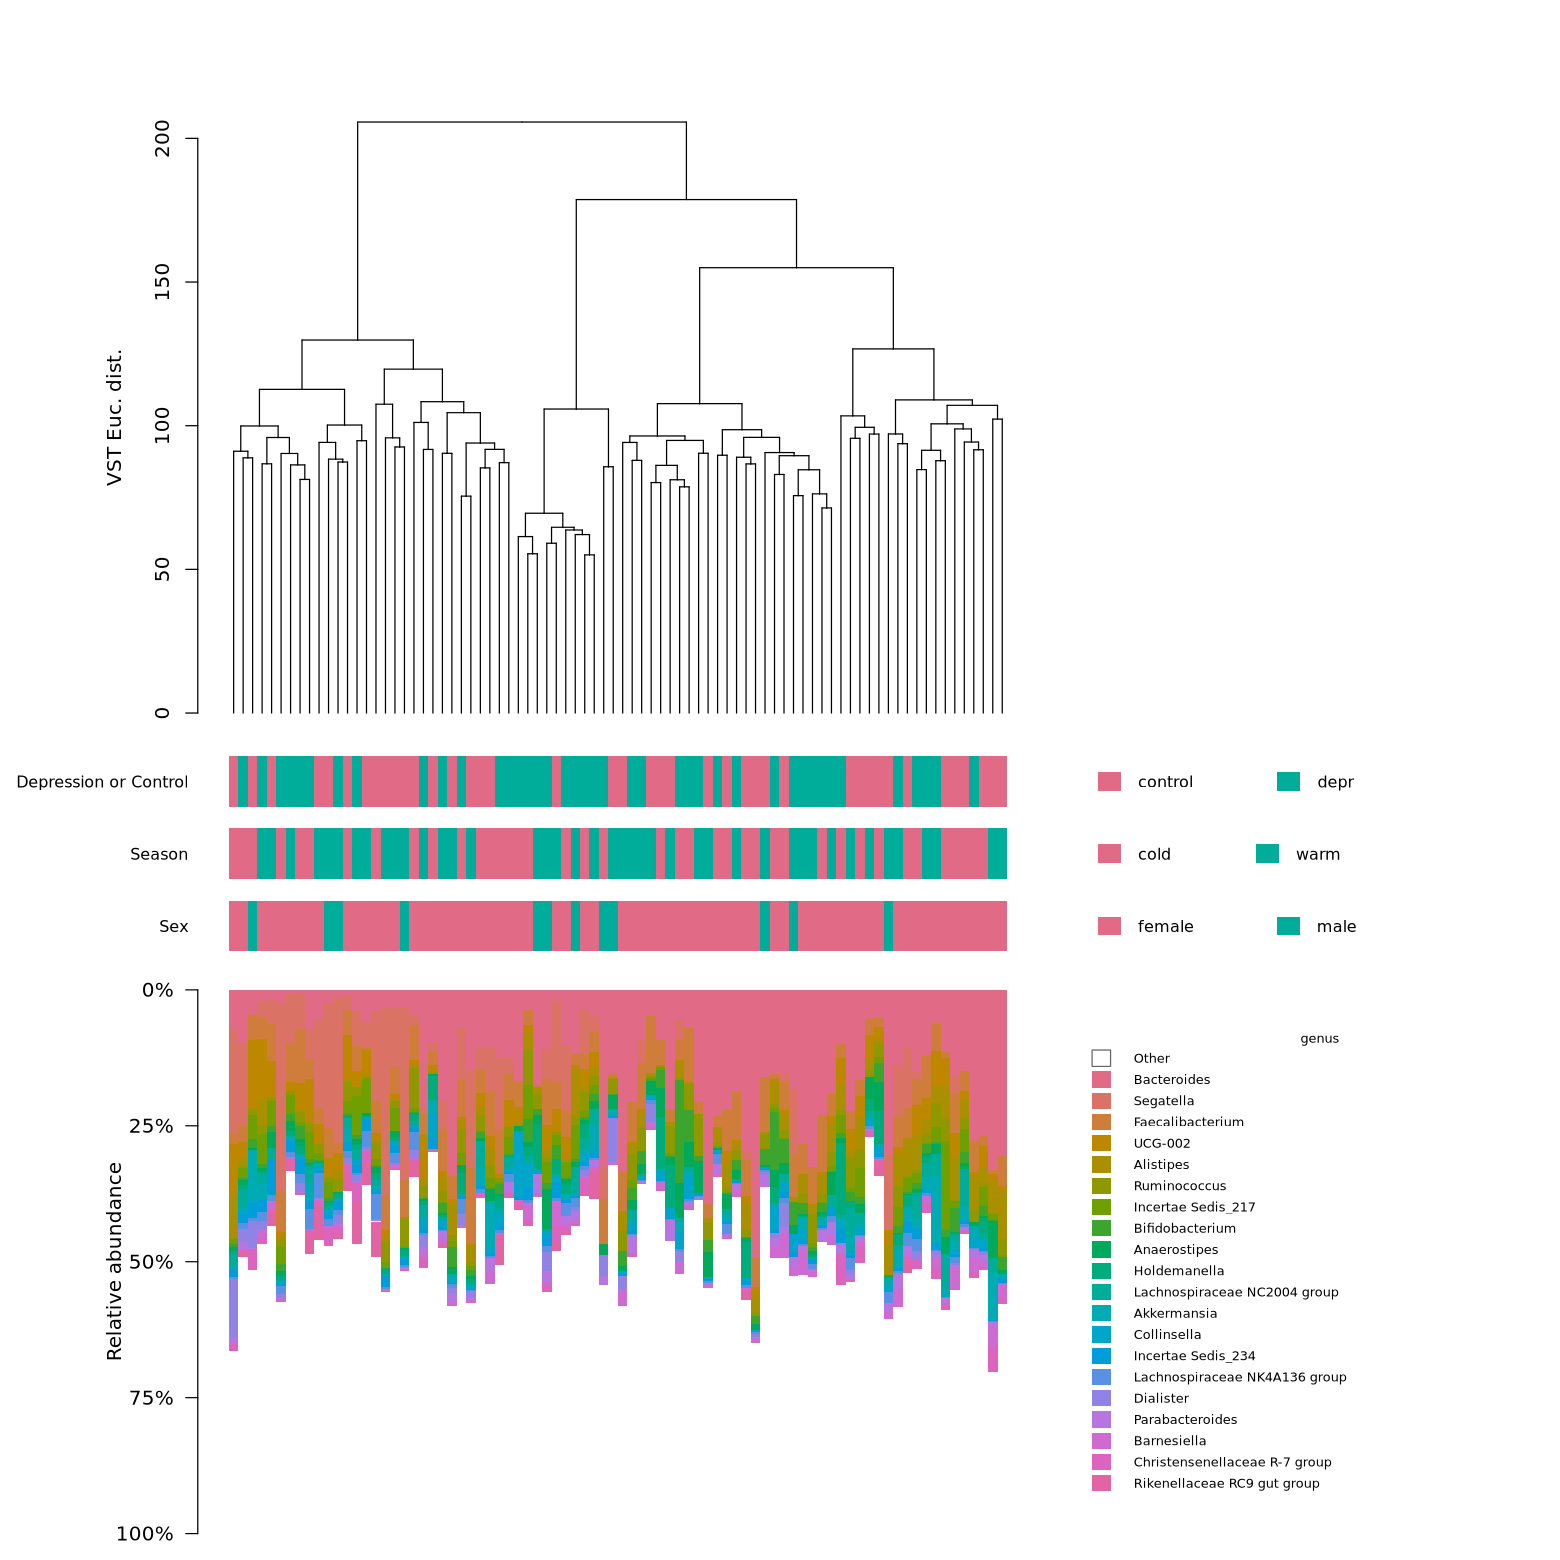

In [11]:
options(repr.plot.width = 13, repr.plot.height = 13)
plot_dendrogram(
    euc_dist_core, ps_core,
    'Depression or Control' = depr_or_control, Season = season, Sex = d_sex,
    taxa_rank = "genus", n_taxa = 20
)

# Beta diversity

## Ordination

Primary coordinates analysis (PCoA) on euclidean coordinate space. Ellipses - 1-SD interval (for bivar normal distr)

In [12]:
source("workflow/scripts/plots/pcoa.R")

Loading required package: permute


Attaching package: ‘vegan’


The following object is masked from ‘package:microbiome’:

    diversity




## ASV-level

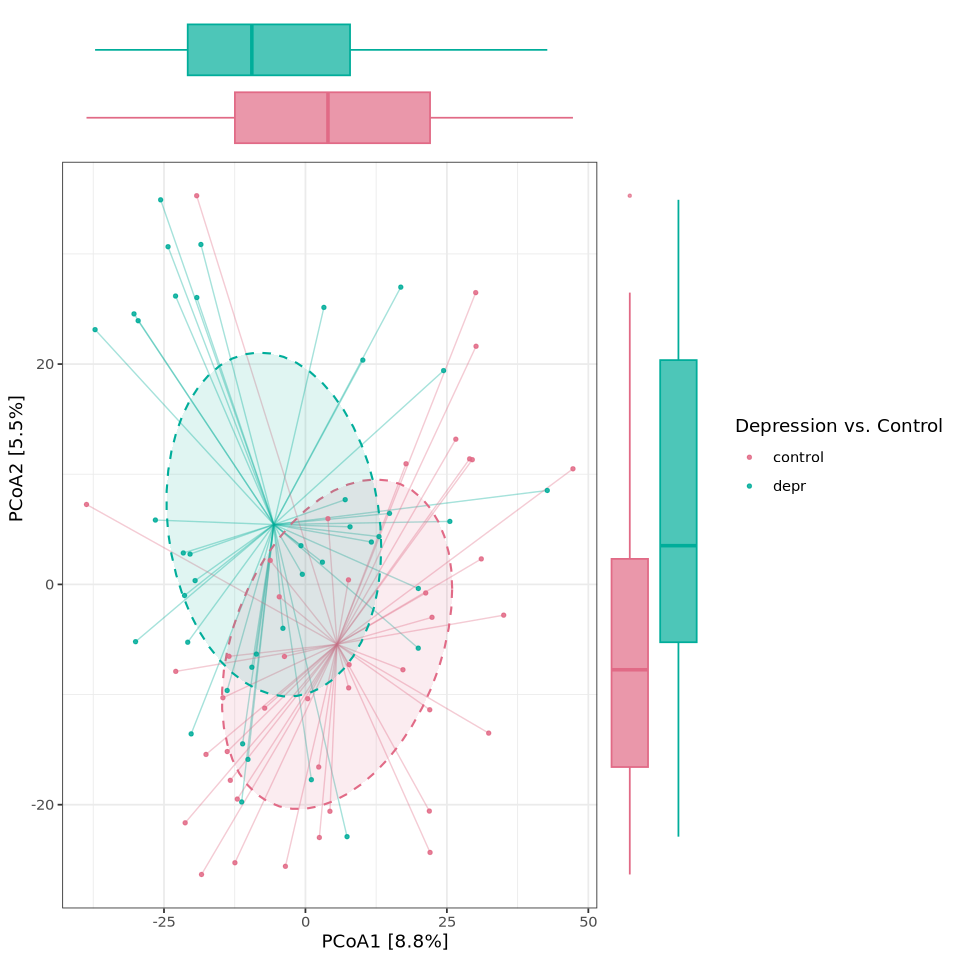

In [13]:
options(repr.plot.width = 8, repr.plot.height = 8)
ord_res <- plot_pcoa(ps_core_vst, euc_dist_core, depr_or_control, legend_title="Depression vs. Control")
pcoa <- ord_res$pcoa

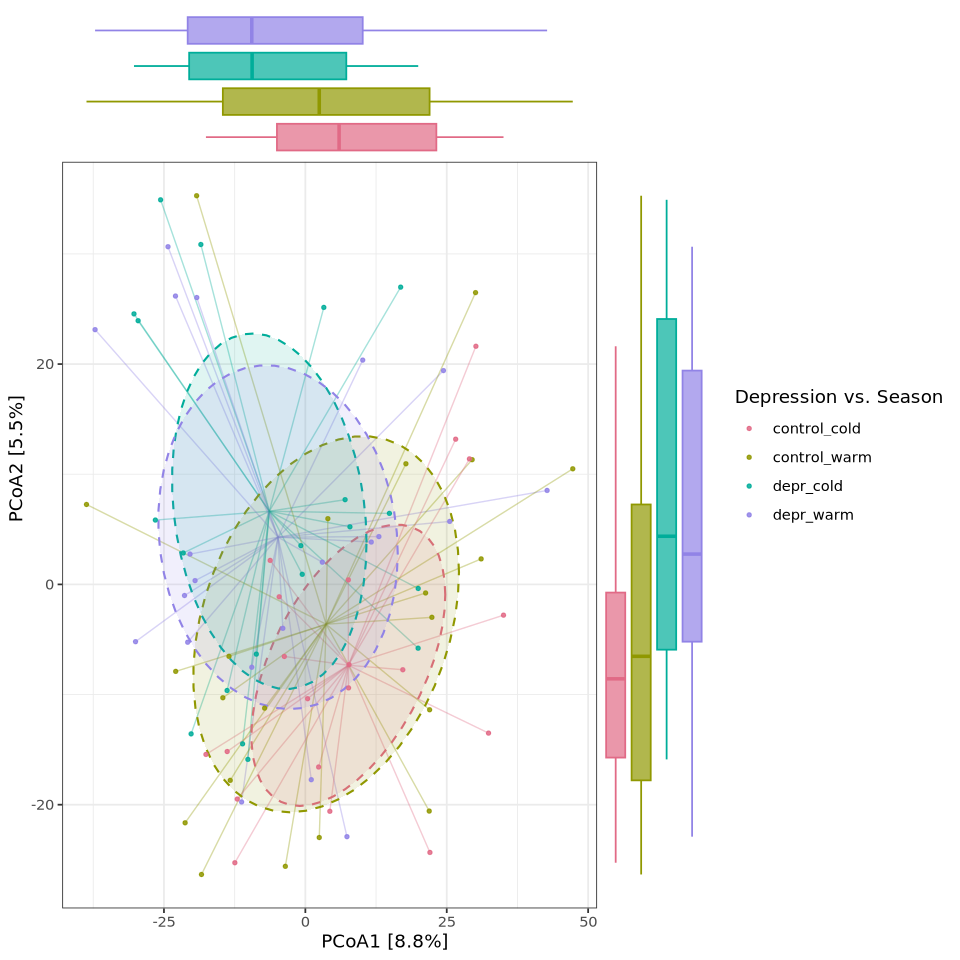

In [14]:
plot_pcoa(ps_core_vst, euc_dist_core, paste(depr_or_control, season, sep="_"), legend_title="Depression vs. Season")

In [15]:
scores <- as.data.frame(pcoa$points)
d2 <- mahalanobis(
    scores,
    colMeans(scores),
    cov(scores)
)
outliers <- which(
    d2 > qchisq(0.975, df = 2)
)

In [16]:
if (length(names(outliers)) == 0) {
    "There is no outlier samples"
} else {
    names(outliers)
}

[1] "There is no outlier samples"

### Stat

Test geterogenety of beta-diversity distributions with `vegan::betadisper`

In [17]:
library(vegan)

Firstly depression vs. control

In [18]:
dc_beta <- betadisper(euc_dist_core, sample_data(ps_core_vst)$depr_or_control)
dc_beta$group.distances |> t()

control,depr
70.30827,63.04693


Average distanses from sample to centers of the groups kindly the same (that likely proofs by same size of the ordination ellipses)

No test significance `vegan::anova`

In [19]:
anova(dc_beta, by='margin')

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,1080.902,1080.90224,22.45465,9.199973e-06
Residuals,80,3850.970,48.13712,NA,NA


So depression and control samples have heterogeneous dispersions, which means I cannot truly trust permanova test on whole set. But amount of samples are the same for depression and control sets. So premanova still valid choice

Use permutation analysis for difference (permanova) with `vegan::adonis2` 

In [20]:
set.seed(08092003)
form_string <- paste("euc_dist_core", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,7968.664,0.02112489,1.739646,0.003
d_sex,1,6651.404,0.01763284,1.452074,0.020
d_age_hc,1,5345.630,0.01417124,1.167009,0.106
Residual,78,357288.708,0.94717086,NA,NA
Total,81,377216.742,1.00000000,NA,NA


now test seasonal depression same way

In [21]:
paste(sample_data(ps_core)$depr_or_control, sample_data(ps_core)$season, sep="_") |> table()


control_cold control_warm    depr_cold    depr_warm 
          20           21           20           21 

In [22]:
seadepr_beta <- betadisper(euc_dist_core, paste(sample_data(ps_core)$depr_or_control, sample_data(ps_core)$season, sep="_"))
seadepr_beta$group.distances |> t()

control_cold,control_warm,depr_cold,depr_warm
68.31052,69.99188,61.8518,62.9626


In [23]:
set.seed(08092003)

form_string <- paste("euc_dist_core", "~", "season * ", rhs)
f <- as.formula(form_string)
f
adonis2(f, meta, permutations = 999, by = 'margin')

euc_dist_core ~ season * depr_or_control + d_sex + d_age_hc

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d_sex,1,6338.982,0.01680461,1.3834774,0.029
d_age_hc,1,4865.460,0.01289832,1.0618827,0.268
season:depr_or_control,1,4543.142,0.01204385,0.9915369,0.443
Residual,76,348225.857,0.92314528,NA,NA
Total,81,377216.742,1.00000000,NA,NA


## Genus level

Firstly aggregate up to genus level

In [24]:
library(DESeq2)
vst_normalization <- function(ps) {
  dds <- phyloseq_to_deseq2(ps, ~ 1)
  dds <- estimateSizeFactors(dds, type = "poscounts")
  dds_vst <- varianceStabilizingTransformation(dds)

  vst_trans_count_tab <- assay(dds_vst)
  euc_dist <- dist(t(vst_trans_count_tab))

  return(list(
    norm_tab = vst_trans_count_tab,
    euclidean_dist = euc_dist
  ))
}

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:dplyr’:

    combine


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, wh

In [25]:
ps_core_genus <- tax_glom(ps_core, taxrank = 'genus')
ps_core_genus

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 201 taxa and 82 samples ]
sample_data() Sample Data:       [ 82 samples by 62 sample variables ]
tax_table()   Taxonomy Table:    [ 201 taxa by 7 taxonomic ranks ]

In [26]:
library(DESeq2)
vst_normalization <- function(ps) {
  dds <- phyloseq_to_deseq2(ps, ~ 1)
  dds <- estimateSizeFactors(dds, type = "poscounts")
  dds_vst <- varianceStabilizingTransformation(dds)

  vst_trans_count_tab <- assay(dds_vst)
  euc_dist <- dist(t(vst_trans_count_tab))

  return(list(
    norm_tab = vst_trans_count_tab,
    euclidean_dist = euc_dist
  ))
}

In [27]:
vst_core_genus <- vst_normalization(ps_core_genus)
ps_core_genus_vst <- phyloseq(
    otu_table(vst_core_genus$norm_tab, taxa_are_rows = T),
    tax_table(ps_core_genus),
    sample_data(ps_core_genus)
)
euc_dist_core_genus <- vst_core_genus$euclidean_dist

converting counts to integer mode



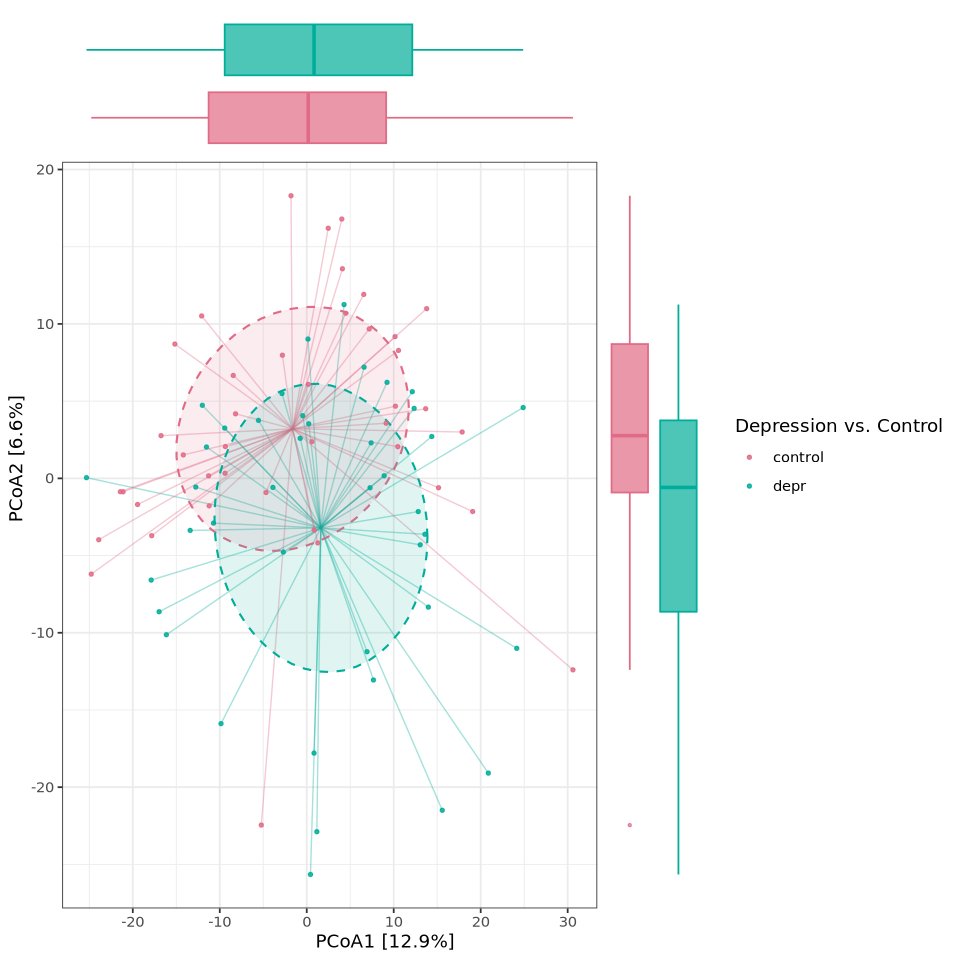

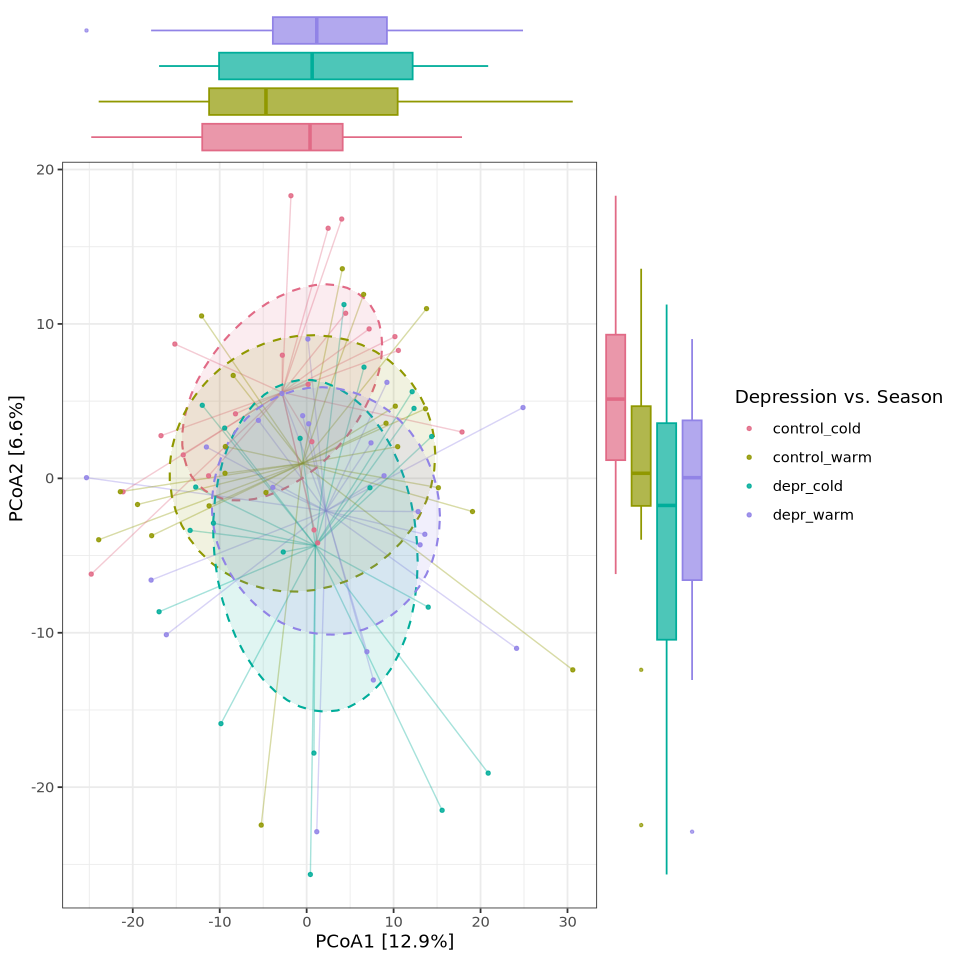

In [28]:
ord_res <- plot_pcoa(ps_core_genus_vst, euc_dist_core_genus, depr_or_control, legend_title="Depression vs. Control")
plot_pcoa(ps_core_genus_vst, euc_dist_core_genus, paste(depr_or_control, season, sep="_"), legend_title="Depression vs. Season")

### Stats

In [29]:
dc_beta_genus <- betadisper(euc_dist_core_genus, sample_data(ps_core_genus_vst)$depr_or_control)
dc_beta_genus$group.distances |> t()
anova(dc_beta_genus, by='margin')
set.seed(08092003)
form_string <- paste("euc_dist_core_genus", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

control,depr
34.87065,34.82283


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,4.689333e-02,0.04689333,0.002870934,0.9574025
Residuals,80,1.306706e+03,16.33382595,NA,NA


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,1767.143,0.01722577,1.418457,0.042
d_sex,1,2296.366,0.02238454,1.843256,0.009
d_age_hc,1,1343.124,0.01309252,1.078104,0.281
Residual,78,97173.997,0.94723361,NA,NA
Total,81,102587.150,1.00000000,NA,NA


In [30]:
seadepr_beta_genus <- betadisper(euc_dist_core, paste(sample_data(ps_core_genus_vst)$depr_or_control, sample_data(ps_core)$season, sep="_"))
seadepr_beta_genus$group.distances |> t()
anova(seadepr_beta_genus, by='margin')
set.seed(08092003)

form_string <- paste("euc_dist_core_genus", "~", "season * ", rhs)
f <- as.formula(form_string)
f
adonis2(f, meta, permutations = 999, by = 'margin')

control_cold,control_warm,depr_cold,depr_warm
68.31052,69.99188,61.8518,62.9626


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,3,975.8951,325.2984,6.80626,0.0003905632
Residuals,78,3727.9320,47.7940,NA,NA


euc_dist_core_genus ~ season * depr_or_control + d_sex + d_age_hc

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d_sex,1,2059.860,0.02007913,1.654871,0.017
d_age_hc,1,1290.033,0.01257500,1.036400,0.342
season:depr_or_control,1,1258.483,0.01226745,1.011052,0.428
Residual,76,94599.166,0.92213465,NA,NA
Total,81,102587.150,1.00000000,NA,NA


# Alpha

In [31]:
source('workflow/scripts/plots/alpha_violins.R')

## ASV level

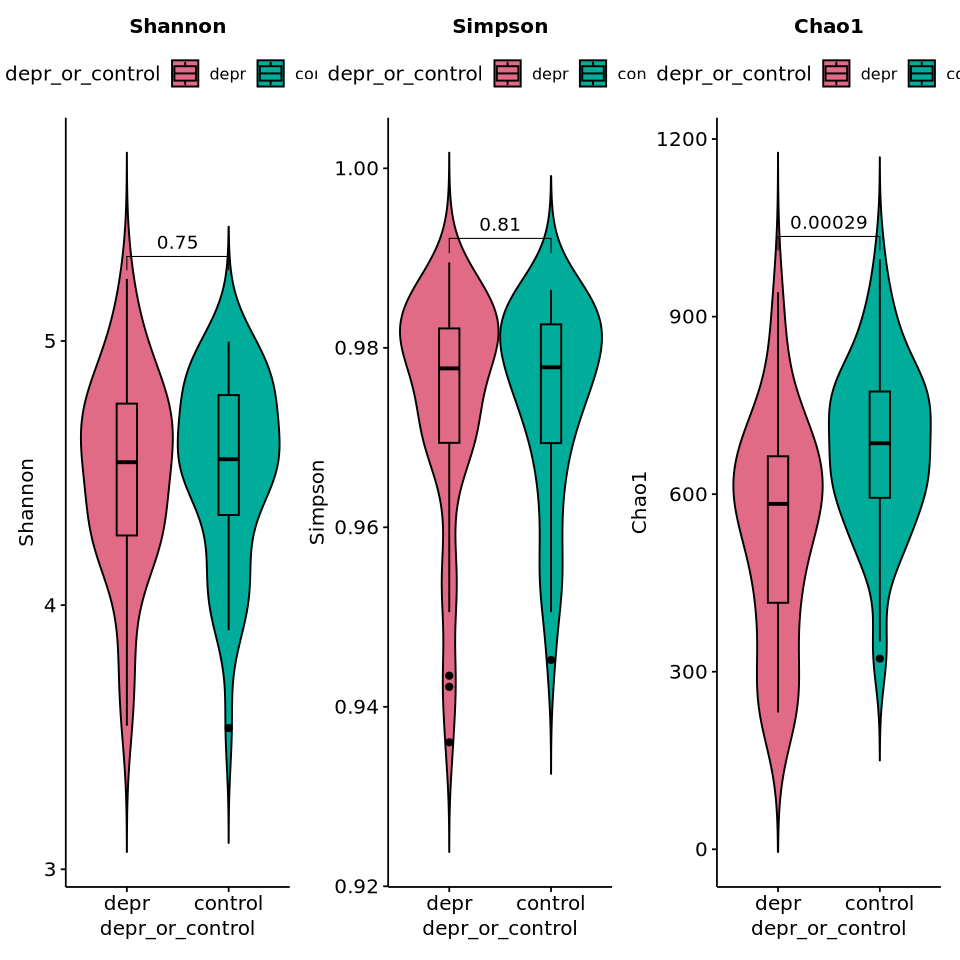

In [32]:
ps_core_no_zero_taxa <- prune_taxa(taxa_sums(ps_core) > 0, ps_core)
alpha <- estimate_richness(ps_core_no_zero_taxa, measures = c("Shannon", "Simpson", "Chao1"))
plot_alpha_violins(cbind(sample_data(ps_core), alpha), "depr_or_control",  c("Shannon", "Simpson", "Chao1"))

## Genus level

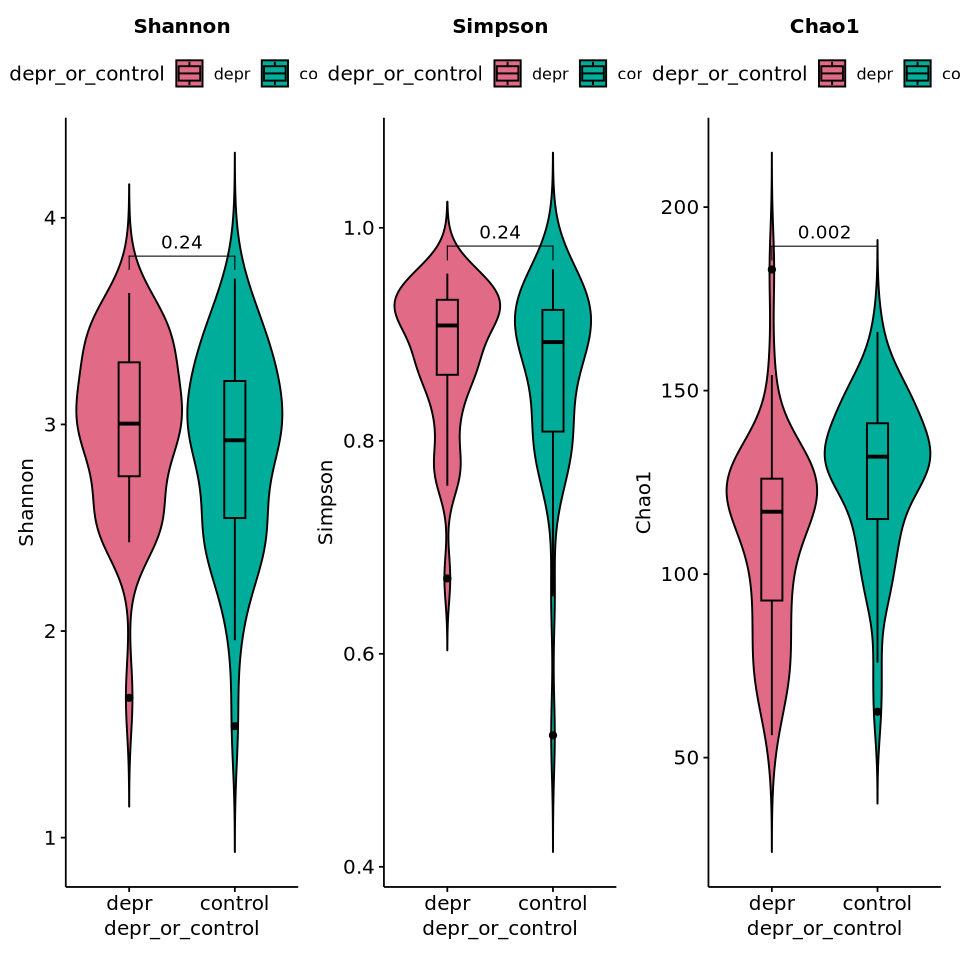

In [33]:
alpha <- estimate_richness(ps_core_genus, measures = c("Shannon", "Simpson", "Chao1"))
plot_alpha_violins(cbind(sample_data(ps_core_genus), alpha), 'depr_or_control', c("Shannon", "Simpson", "Chao1"))

# DMM (Dirichlet multinomial mixtures)

In [34]:
library(DirichletMultinomial)
library(lattice)

In [35]:
.qualitative <- DirichletMultinomial:::.qualitative

In [49]:
counts <- otu_table(ps_core_genus) |> t()

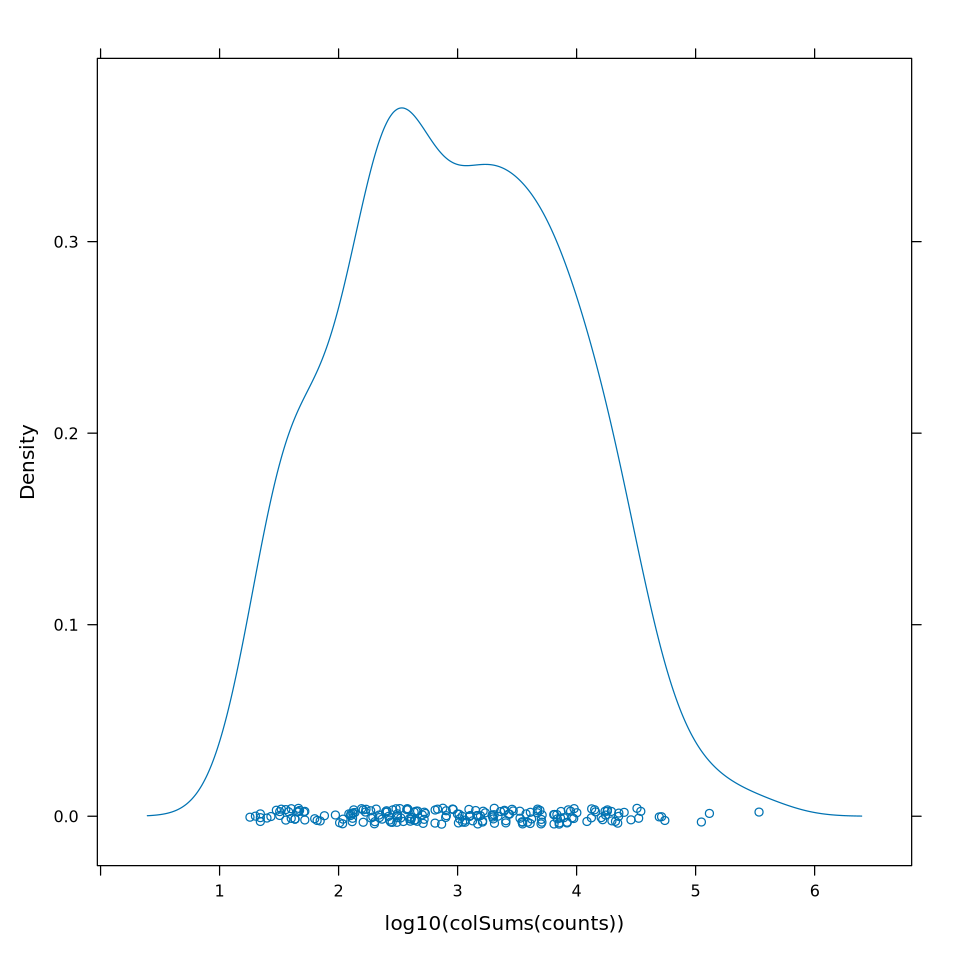

In [37]:
densityplot(
    log10(colSums(counts))
)

In [65]:
fit <- lapply(1:8, dmn, count=counts, verbose=TRUE)

dmn, k=1



  Soft kmeans
  Expectation Maximization setup
  Expectation Maximization
  Hessian


dmn, k=2



  Soft kmeans
    iteration 10 change 0.000796
    iteration 20 change 0.000005
  Expectation Maximization setup
  Expectation Maximization
    iteration 10 change 0.663546
    iteration 20 change 7.371493
    iteration 30 change 0.480919
    iteration 40 change 0.124052
  Hessian


dmn, k=3



...

  Soft kmeans
    iteration 10 change 0.007703
    iteration 20 change 0.004179
    iteration 30 change 0.005501
    iteration 40 change 0.000171
    iteration 50 change 0.000030
    iteration 60 change 0.000006
    iteration 70 change 0.000001
  Expectation Maximization setup
  Expectation Maximization
    iteration 10 change 12.901710
  Hessian


dmn, k=7



  Soft kmeans
    iteration 10 change 0.022733
    iteration 20 change 0.001025
    iteration 30 change 0.000167
    iteration 40 change 0.000031
    iteration 50 change 0.000006
    iteration 60 change 0.000001
  Expectation Maximization setup
  Expectation Maximization
    iteration 10 change 0.000004
  Hessian


dmn, k=8



  Soft kmeans
    iteration 10 change 0.023689
    iteration 20 change 0.004463
    iteration 30 change 0.001717
    iteration 40 change 0.000677
    iteration 50 change 0.000152
    iteration 60 change 0.000029
    iteration 70 change 0.000005
    iteration 80 change 0.000001
  Expectation Maximization setup
  Expectation Maximization
  Hessian


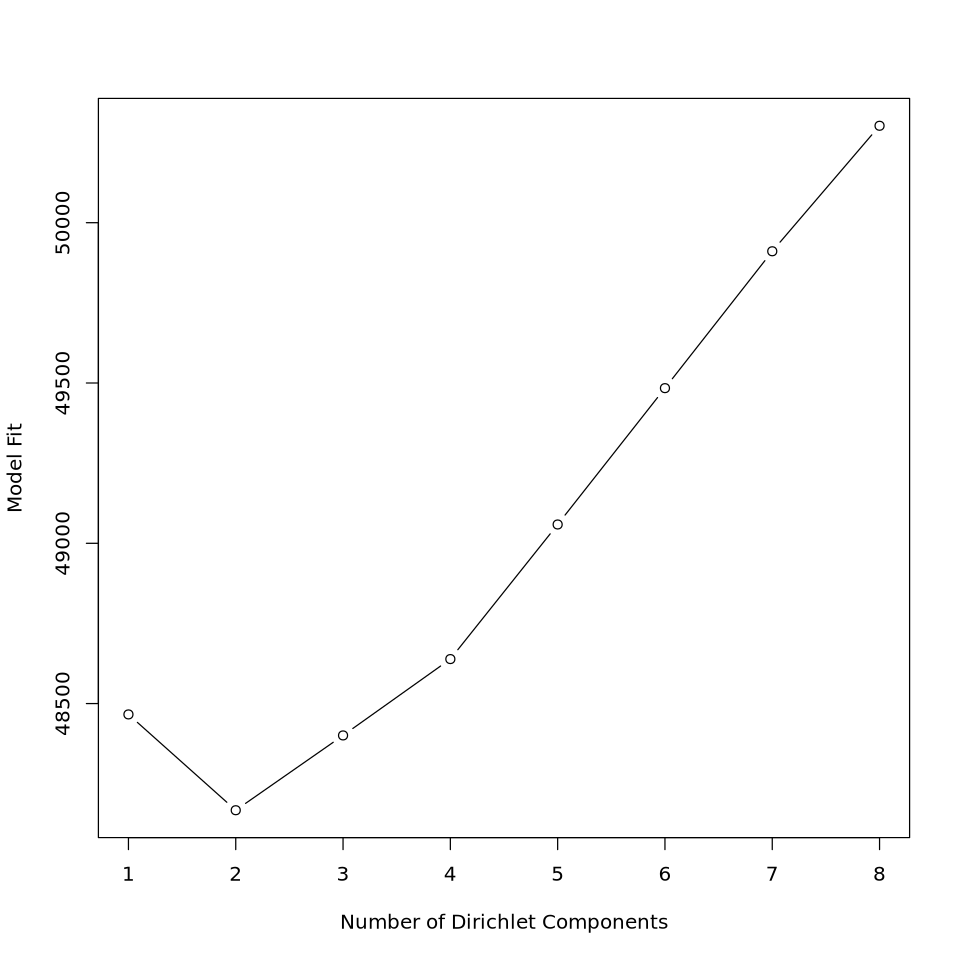

In [66]:
lplc <- sapply(fit, laplace)
plot(lplc, type="b", xlab="Number of Dirichlet Components", ylab="Model Fit")

In [68]:
(best <- fit[[which.min(lplc)]])

class: DMN 
k: 2 
samples x taxa: 82 x 201 
Laplace: 48167.34 BIC: 48890.1 AIC: 48405.14 

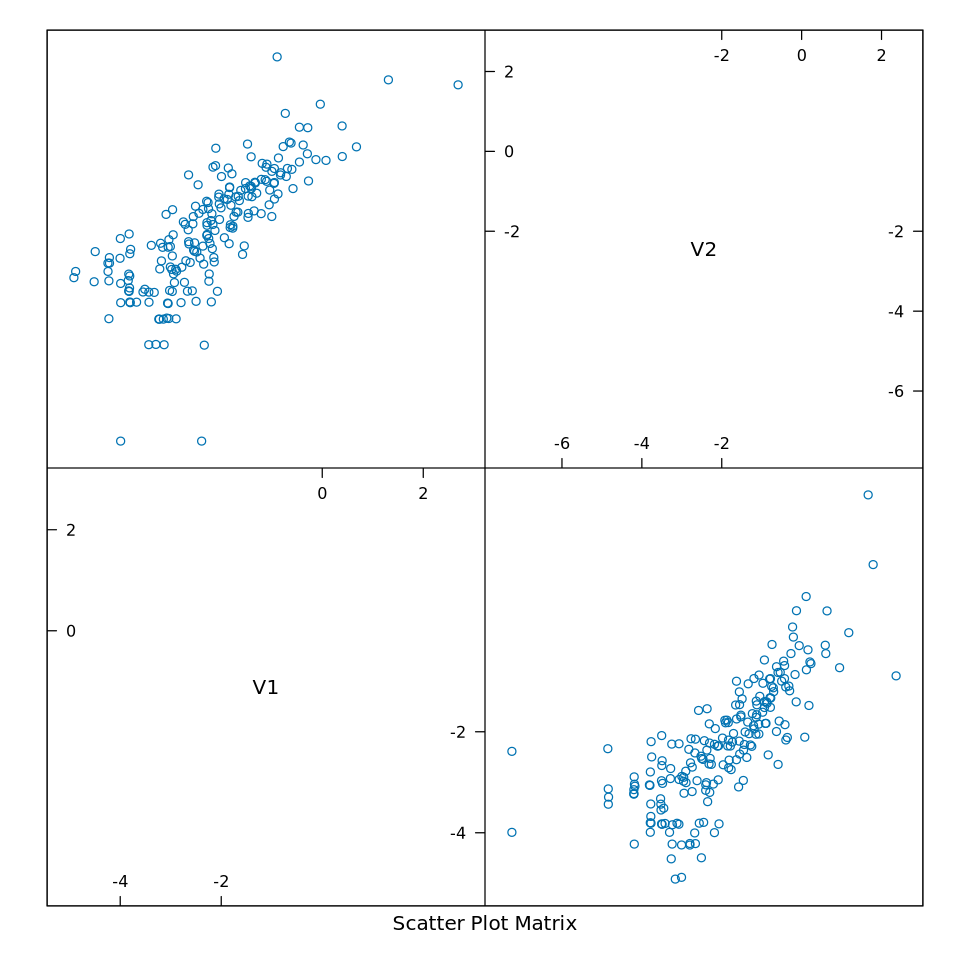

In [69]:
splom(log(fitted(fit[[2]])))

In [74]:
head(mixture(best, assign = T))

SRR32393695 SRR32393200 SRR32393737 SRR32393342 SRR32393459 SRR32393479 
          2           2           1           1           1           1

In [ ]:
meta$dmm_cluster = factor(mixture(best, assign = T))

In [106]:
table(meta$dmm_cluster)


 1  2 
53 29 

In [89]:
xtab <- xtabs(~ depr_or_control + dmm_cluster, data = meta)
xtab

               dmm_cluster
depr_or_control  1  2
        control 26 15
        depr    27 14

In [102]:
chisq.test(xtab, simulate.p.value = T)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  xtab
X-squared = 0.053351, df = NA, p-value = 1


In [90]:
fisher.test(xtab)


	Fisher's Exact Test for Count Data

data:  xtab
p-value = 1
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3291405 2.4483102
sample estimates:
odds ratio 
 0.8999374 


In [104]:
form_string <- paste("dmm_cluster", "~", rhs)
f <- as.formula(form_string)
f

dmm_cluster ~ depr_or_control + d_sex + d_age_hc

In [107]:
summary(model <- nnet::multinom(f, data = meta))

# weights:  5 (4 variable)


initial  value 56.838069 
final  value 53.166050 
converged


Call:
nnet::multinom(formula = f, data = meta)

Coefficients:
                          Values  Std. Err.
(Intercept)         -1.070378524 1.49472964
depr_or_controldepr -0.108382935 0.46264320
d_sexmale           -0.071378628 0.66835998
d_age_hc             0.009097485 0.02468251

Residual Deviance: 106.3321 
AIC: 114.3321 

In [108]:
car::Anova(model, type="III")

,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
depr_or_control,0.05490849,1,0.8147322
d_sex,0.01146506,1,0.9147295
d_age_hc,0.13678302,1,0.7115003


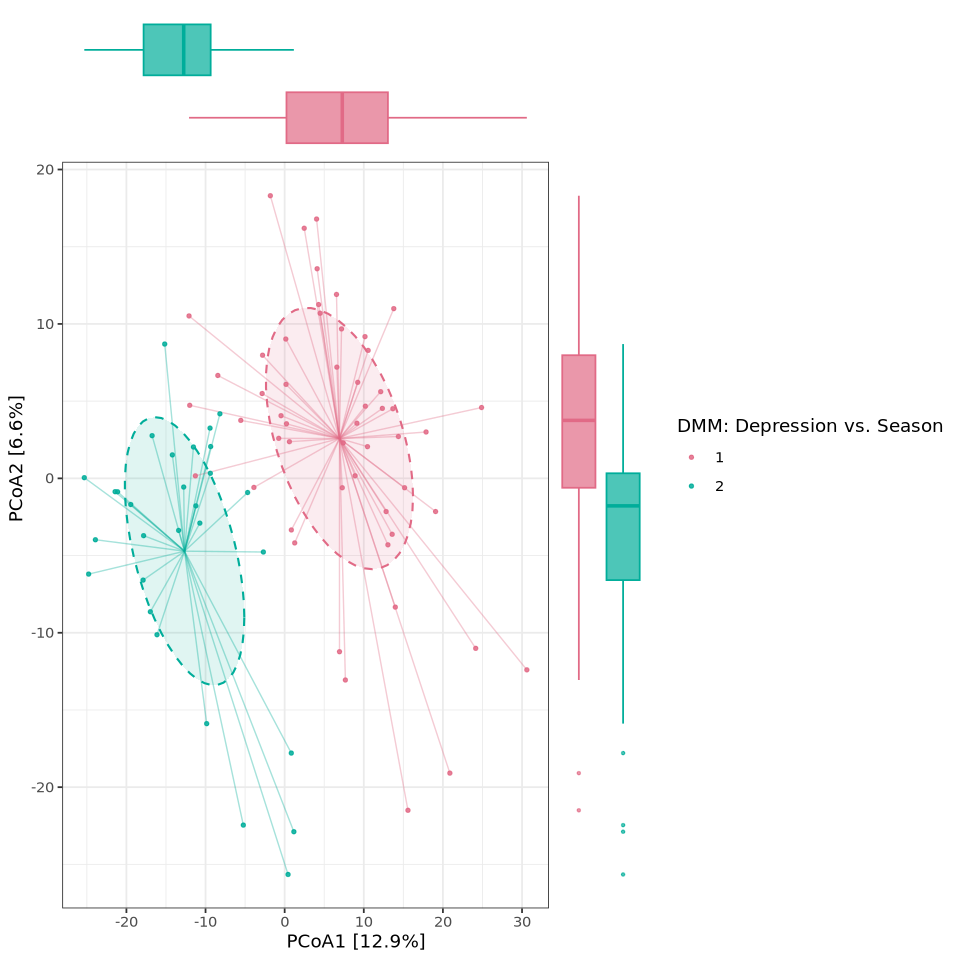

In [111]:
sample_data(ps_core_genus) <- meta
sample_data(ps_core_genus_vst) <- meta
plot_pcoa(
    ps_core_genus_vst,
    euc_dist_core_genus, 
    dmm_cluster,
    legend_title="DMM: Depression vs. Season")

# Retest these results using CLR normalization and Bray-Curtis distances

In [43]:
library(vegan)
library(phyloseq)
library(microbiome)

In [44]:
set.seed(08092003)
ps_core_rare <- rarefy_even_depth(ps_core, rngseed = 08092003)

`set.seed(8092003)` was used to initialize repeatable random subsampling.

Please record this for your records so others can reproduce.

Try `set.seed(8092003); .Random.seed` for the full vector

...

356OTUs were removed because they are no longer 
present in any sample after random subsampling


...



In [45]:
bray_dist_core <- phyloseq::distance(ps_core_rare, method = "bray")

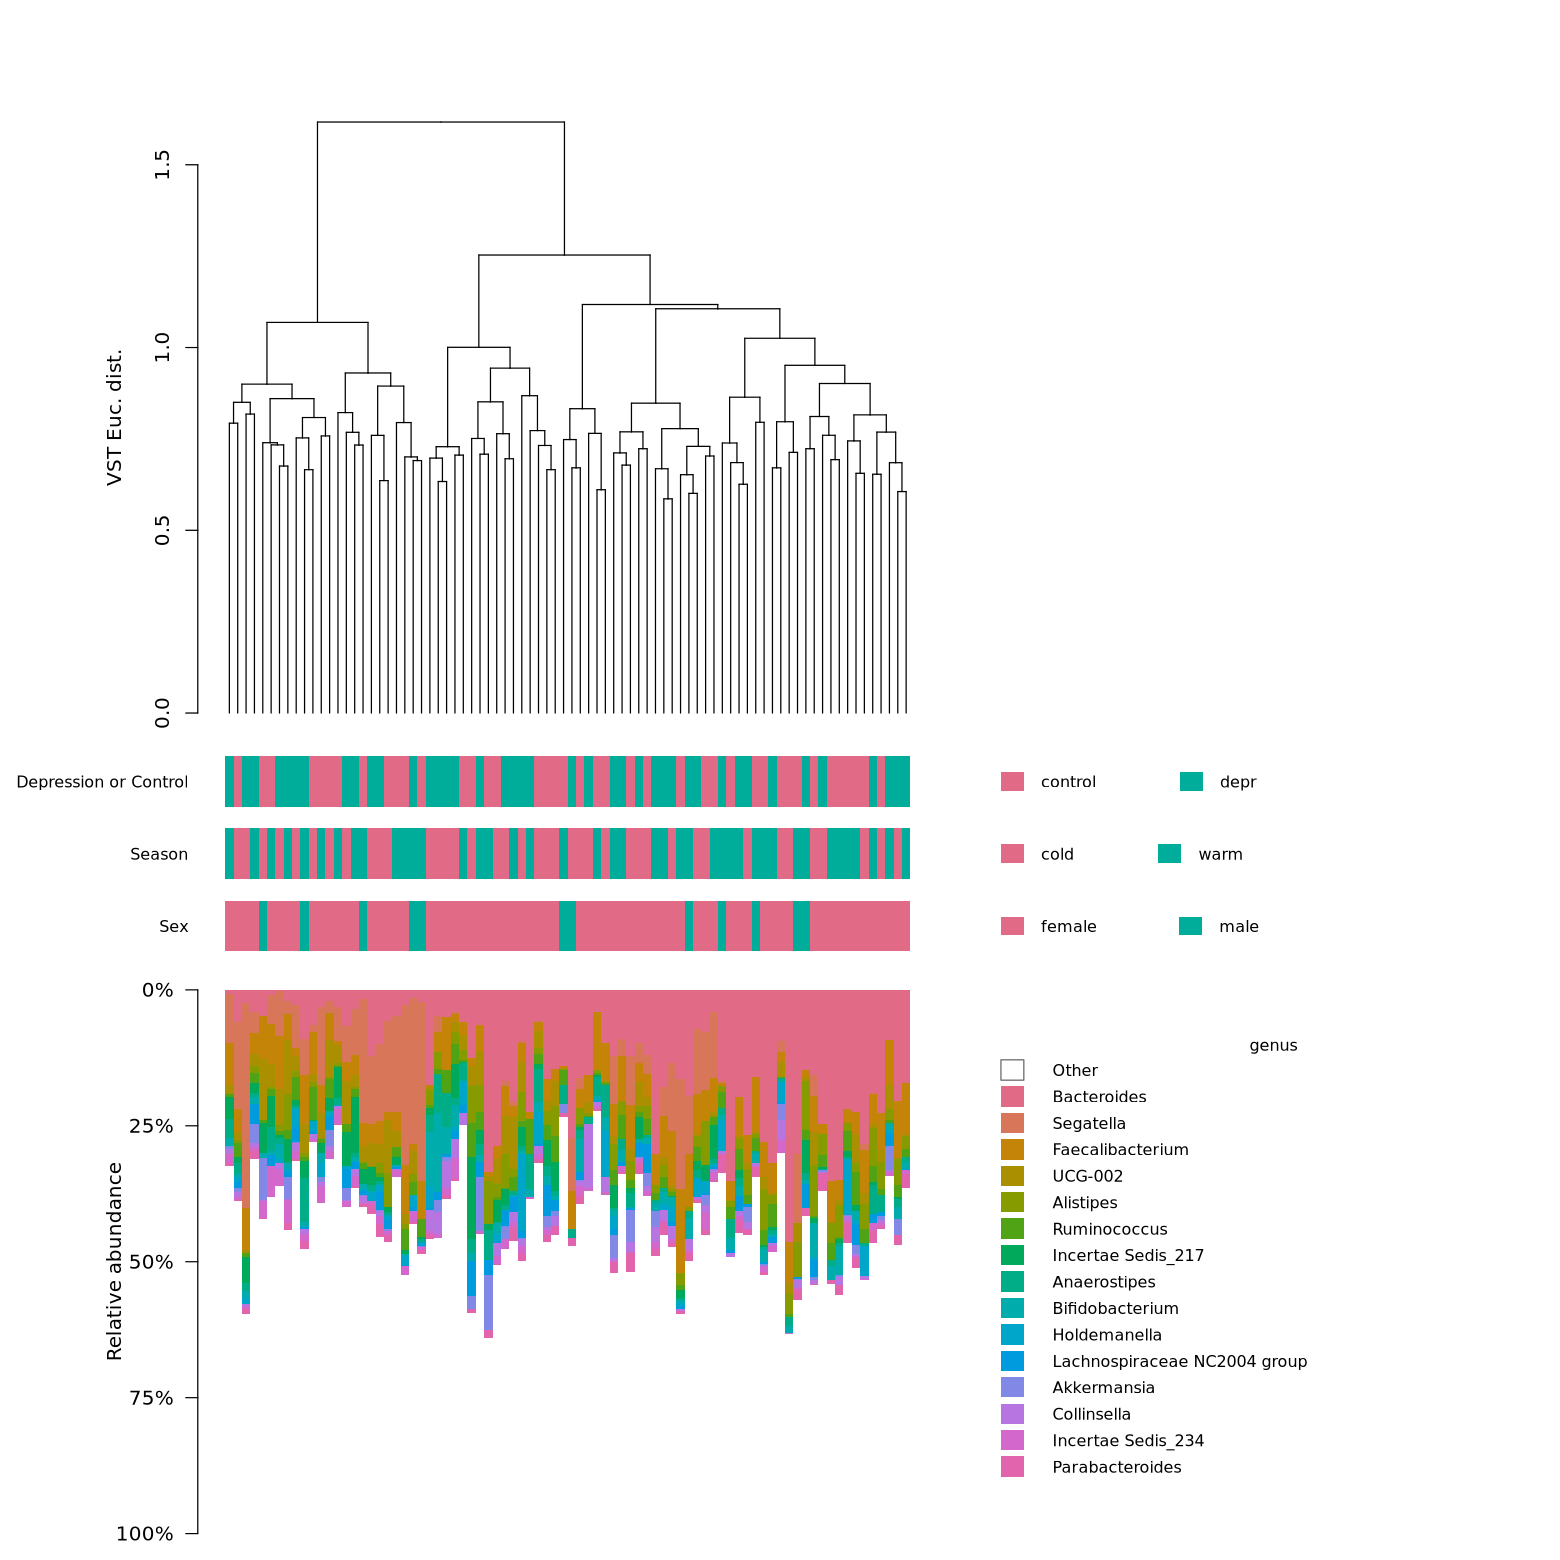

In [46]:
options(repr.plot.width = 13, repr.plot.height = 13)
plot_dendrogram(
    bray_dist_core, ps_core_rare,
    'Depression or Control' = depr_or_control, Season = season, Sex = d_sex,
    taxa_rank = "genus", n_taxa = 15
)

In [47]:
options(repr.plot.width = 8, repr.plot.height = 8)
plot_pcoa(ps_core_clr, bray_dist_core, depr_or_control, legend_title="Depression vs. Control")

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': error in evaluating the argument 'object' in selecting a method for function 'sample_data': object 'ps_core_clr' not found


In [ ]:
dc_beta_bray <- betadisper(bray_dist_core, sample_data(ps_core_clr)$depr_or_control)
dc_beta_bray$group.distances |> t()

anova(dc_beta_bray, by='margin')

set.seed(08092003)
form_string <- paste("bray_dist_core", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

control,depr
0.5644687,0.5496247


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,0.004517029,0.004517029,2.031549,0.1579535
Residuals,80,0.177875227,0.002223440,NA,NA


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,0.2627566,0.010152507,0.8221356,0.910
d_sex,1,0.4214574,0.016284461,1.3186925,0.023
d_age_hc,1,0.2510705,0.009700975,0.7855712,0.948
Residual,78,24.9289972,0.963217717,NA,NA
Total,81,25.8809579,1.000000000,NA,NA
